# Determine And Validate The RNA Preprocessing Rules

## Purpose

**This notebook evaluates preprocessing choices for RNA expression data after EDA filtering.**

### Objectives:
- Examine RNA expression distributions
- Evaluate low-expression filtering strategies
- Evaluate variance-based feature filtering
- Assess scaling effects on gene expression features
- Prototype preprocessing steps before implementation in the pipeline

### Workflow

1. Load filtered RNA expression dataset  
   - Dataset already passed validity filtering during EDA.

2. Load split IDs and partition the dataset  
   - Create `X_train`, `X_val`, `X_test` using the saved split.

**Subsequent exploratory steps use the training data only.**

3. Inspect expression distributions  
   - Examine overall gene expression distributions across samples.  
   - Identify potential skew, heavy tails, or extreme values.

4. Evaluate low-expression filtering  
   - Explore thresholds for removing genes with consistently low expression.  
   - Assess impact on feature count and expression distribution.

5. Evaluate variance filtering  
   - Identify genes with near-zero variance across samples.  
   - Assess potential thresholds for removing uninformative genes.

6. Assess scaling effects  
   - Evaluate the effect of standardization on expression features.  
   - Confirm scaling behavior across genes.

7. Formalize and save preprocessing rules as JSON for downstream use.
   - Collect the defined parameters and save as JSON, also save enough metadata to make the rule file self-describing.

**Subsequent steps contain development code that is prototyped and validated in the notebook before being refactored into the module.**

8. Fit preprocessing parameters on the training set only  
   - Compute filtering thresholds and scaling parameters using `X_train`.

9. Apply preprocessing to all splits  
   - Transform train, validation, and test using parameters learned from the training set.

10. Validate outputs  
   - Confirm expected feature counts after filtering  
   - Verify row counts match split sizes  
   - Verify no ID drift or leakage

11. Test preprocessing module

In [1]:
from pathlib import Path
import json
import subprocess

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

## 1. Load filtered RNA expression dataset  
   - Dataset already passed validity filtering during EDA.

In [2]:
# Load the filtered RNA cohort by keeping only the saved sample IDs.
rna_path = Path("../data/raw/TCGA-BRCA.star_tpm.tsv.gz")
sample_ids_df = pd.read_csv("../data/interim/sample_ids_cohort.csv")

sample_ids = sample_ids_df["sample"].astype(str)
rna_df = pd.read_csv(rna_path, sep="\t")

if "Ensembl_ID" not in rna_df.columns:
    raise KeyError("Expected 'Ensembl_ID' column in RNA expression table")

missing_sample_ids = sorted(set(sample_ids) - set(rna_df.columns))
if missing_sample_ids:
    raise KeyError(f"Filtered sample IDs missing from RNA table: {missing_sample_ids[:5]}")

# Keep genes as features and samples as rows for downstream splitting.
rna_df = (
    rna_df.set_index("Ensembl_ID")
    .loc[:, sample_ids]
    .T
)
rna_df.index.name = "sample"

print(f"RNA shape (samples x genes): {rna_df.shape}")
display(rna_df.head(), rna_df.tail())

RNA shape (samples x genes): (290, 60660)


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-3C-AAAU-01A,3.407747,0.125387,6.712645,3.358185,2.264056,2.563549,3.112116,4.795622,3.737081,5.948982,...,0.0,0.000000,0.601316,0.0,0.0,0.000000,4.962211,0.0,0.179256,1.284100
TCGA-3C-AALI-01A,3.228680,0.167486,7.107211,5.052007,3.080419,3.514173,4.391307,5.583462,4.177344,4.947381,...,0.0,1.330329,0.806860,0.0,0.0,0.032524,3.900162,0.0,0.117695,1.779932
TCGA-A1-A0SK-01A,6.590713,0.000000,7.653724,3.384616,3.907929,1.733311,2.307370,5.456110,4.120941,6.433409,...,0.0,0.000000,0.146655,0.0,0.0,0.000000,3.574804,0.0,0.030124,0.682753
TCGA-A2-A04N-01A,5.665933,0.288418,6.524913,3.503972,2.447156,2.538414,4.421715,5.488293,4.331956,5.614557,...,0.0,0.000000,0.544485,0.0,0.0,0.000000,3.993702,0.0,0.029135,0.979733
TCGA-A2-A04Q-01A,4.769962,0.195348,6.077078,3.461529,2.534908,4.497389,4.031960,5.251401,3.198227,5.382142,...,0.0,0.000000,0.144177,0.0,0.0,0.000000,3.404794,0.0,0.038015,0.665302


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-PE-A5DD-01A,4.593270,1.214000,6.272486,4.041217,3.159532,3.589260,4.791069,5.397139,3.373913,5.326721,...,0.0,0.0,0.988703,0.0,0.0,0.000000,2.385652,0.0,0.196355,1.047329
TCGA-PE-A5DE-01A,3.057242,0.639325,6.935899,4.346141,3.010064,4.666876,4.787088,4.581002,3.403936,5.482932,...,0.0,0.0,0.451646,0.0,0.0,0.000000,3.220748,0.0,0.108089,0.985355
TCGA-V7-A7HQ-01A,5.278453,0.325847,5.477891,2.152183,0.690551,1.788686,2.869556,5.829055,3.082890,4.157084,...,0.0,0.0,0.091666,0.0,0.0,0.000000,2.764537,0.0,0.044184,1.893751
TCGA-Z7-A8R5-01A,5.526410,0.674551,6.273221,3.354353,1.419431,4.602688,4.369222,5.659548,2.981177,4.529908,...,0.0,0.0,0.324926,0.0,0.0,0.028711,2.736843,0.0,0.058801,1.280006
TCGA-Z7-A8R6-01A,5.003499,0.339023,6.923104,3.757770,3.868114,3.141400,2.935064,5.057849,3.228295,5.447358,...,0.0,0.0,0.485736,0.0,0.0,0.000000,3.481661,0.0,0.028993,1.536501


## 2. Load split IDs and partition the dataset  
   - Create `X_train`, `X_val`, `X_test` using the saved split.

In [3]:
# Load saved split IDs and partition the RNA dataset by sample.
split_dir = Path("../data/processed/splits/os_seed42_v15_t15")

train_ids_df = pd.read_csv(split_dir / "train_ids.csv")
val_ids_df = pd.read_csv(split_dir / "val_ids.csv")
test_ids_df = pd.read_csv(split_dir / "test_ids.csv")

train_ids = train_ids_df["sample"].astype(str)
val_ids = val_ids_df["sample"].astype(str)
test_ids = test_ids_df["sample"].astype(str)

missing_ids = sorted((set(train_ids) | set(val_ids) | set(test_ids)) - set(rna_df.index))
if missing_ids:
    raise KeyError(f"Split sample IDs missing from rna_df: {missing_ids[:5]}")

# Keep split order fixed so downstream comparisons stay aligned across modalities.
X_train_df = rna_df.loc[train_ids].copy()
X_val_df = rna_df.loc[val_ids].copy()
X_test_df = rna_df.loc[test_ids].copy()

print(f"train: {X_train_df.shape}")
print(f"val:   {X_val_df.shape}")
print(f"test:  {X_test_df.shape}")
display(X_train_df.head(), X_train_df.tail())


train: (203, 60660)
val:   (43, 60660)
test:  (44, 60660)


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AR-A1AN-01A,4.136962,1.340391,6.126083,3.469365,2.488952,3.092038,5.305310,5.972906,4.263613,5.541366,...,0.0,0.0,0.242572,0.0,0.000000,0.0,4.139371,0.0,0.008630,1.517981
TCGA-B6-A2IU-01A,4.087047,1.623258,6.016039,5.286083,3.669526,2.460087,3.389126,4.965530,4.565177,5.943427,...,0.0,0.0,0.318461,0.0,0.000000,0.0,4.117537,0.0,0.056445,0.543001
TCGA-C8-A12Q-01A,5.143761,1.293017,7.245631,4.338146,3.223716,3.880284,5.129254,5.493731,4.278594,5.370028,...,0.0,0.0,0.318577,0.0,0.000000,0.0,4.181667,0.0,0.065986,0.521955
TCGA-BH-A0E9-01B,6.761509,1.384271,6.749827,4.912942,3.892906,3.541341,5.536118,5.905336,3.981761,6.115972,...,0.0,0.0,0.466027,0.0,1.079498,0.0,4.501280,0.0,0.098420,1.036327
TCGA-A2-A0ST-01A,5.294275,0.854474,6.285212,3.034726,2.585732,4.877587,4.336462,5.668272,3.225260,5.522232,...,0.0,0.0,0.207518,0.0,0.000000,0.0,2.806901,0.0,0.053389,0.849999


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-GM-A2DM-01A,6.403268,0.070939,6.505716,3.298204,1.804921,3.107119,2.665802,6.461699,5.408236,5.437391,...,0.0,0.0,0.226262,0.0,0.000000,0.0,3.883709,0.0,0.076149,1.135206
TCGA-AR-A2LE-01A,6.643308,0.384492,5.785514,4.133588,2.392427,2.037031,4.085059,5.312110,4.510905,5.224361,...,0.0,0.0,0.526770,0.0,0.000000,0.0,3.897240,0.0,0.066124,0.655352
TCGA-E2-A1LK-01A,5.512546,0.000000,7.019724,3.237120,2.695437,3.149845,1.664528,6.021271,3.353450,5.099480,...,0.0,0.0,0.206893,0.0,0.000000,0.0,4.087870,0.0,0.013069,0.792855
TCGA-E9-A1RB-01A,4.570669,0.161436,7.336596,3.950067,4.061197,2.840040,4.378331,5.724260,3.113200,4.963997,...,0.0,0.0,0.530570,0.0,0.000000,0.0,4.288329,0.0,0.038717,0.810649
TCGA-B6-A0I6-01A,5.543199,0.000000,7.148059,2.944334,2.548905,2.791147,4.206674,6.101925,3.907929,4.812565,...,0.0,0.0,0.061569,0.0,1.236768,0.0,3.271426,0.0,0.119024,0.198871


## 3. Inspect expression distributions  
   - Examine overall gene expression distributions across samples.  
   - Identify potential skew, heavy tails, or extreme values.



,mean_expression,median_expression,variance
Ensembl_ID,,,
ENSG00000000003.15,5.052530,5.064572,0.991125
ENSG00000000005.6,0.966997,0.636543,0.977202
ENSG00000000419.13,6.858716,6.796495,0.391257
ENSG00000000457.14,3.881653,3.918386,0.457295
ENSG00000000460.17,2.947533,2.937382,0.566260


,mean_expression,median_expression,variance
Ensembl_ID,,,
ENSG00000288669.1,0.001980,0.000000,0.000080
ENSG00000288670.1,3.852839,3.864018,0.453517
ENSG00000288671.1,0.000000,0.000000,0.000000
ENSG00000288674.1,0.068532,0.052694,0.002814
ENSG00000288675.1,0.971507,0.896466,0.199710


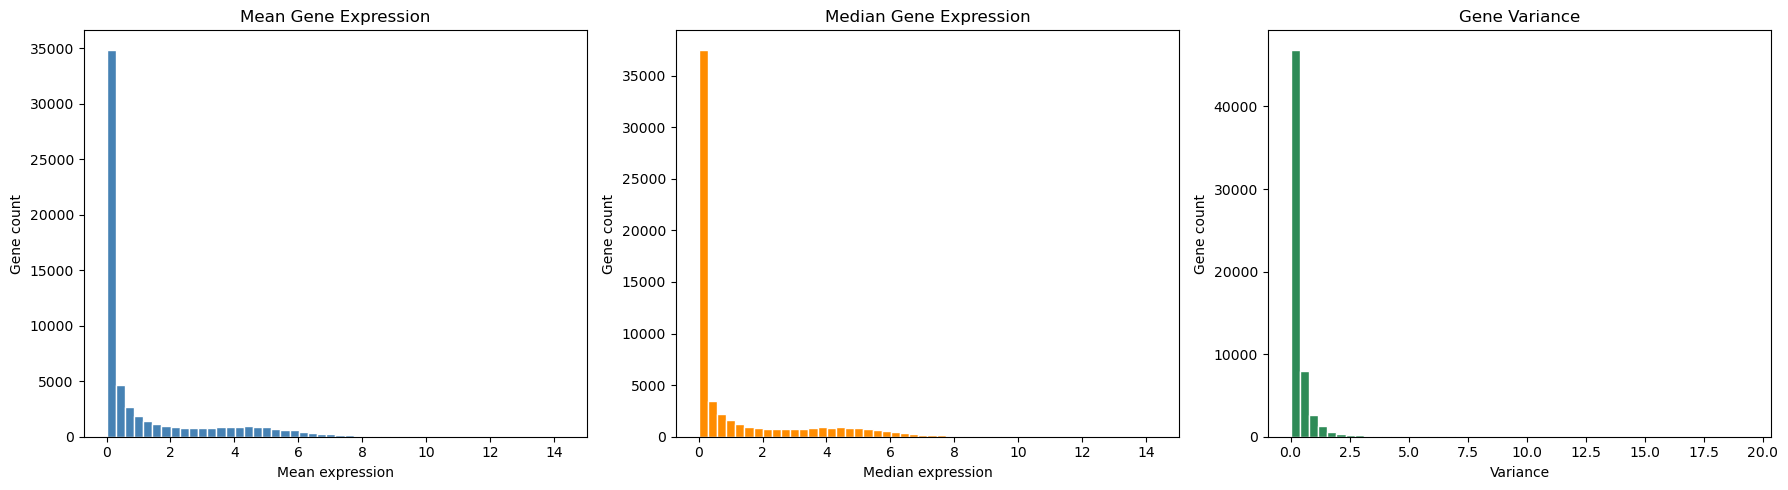

In [4]:
# Summarize train-only gene expression to guide low-expression and variance filtering.
if X_train_df.empty:
    raise ValueError("X_train_df is empty")

gene_summary_df = pd.DataFrame({
    "mean_expression": X_train_df.mean(axis=0),
    "median_expression": X_train_df.median(axis=0),
    "variance": X_train_df.var(axis=0),
})

display(gene_summary_df.head(), gene_summary_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(gene_summary_df["mean_expression"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Mean Gene Expression")
axes[0].set_xlabel("Mean expression")
axes[0].set_ylabel("Gene count")

axes[1].hist(gene_summary_df["median_expression"], bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Median Gene Expression")
axes[1].set_xlabel("Median expression")
axes[1].set_ylabel("Gene count")

axes[2].hist(gene_summary_df["variance"], bins=50, color="seagreen", edgecolor="white")
axes[2].set_title("Gene Variance")
axes[2].set_xlabel("Variance")
axes[2].set_ylabel("Gene count")

plt.tight_layout()
plt.show()


,detection_rate_tpm_gt_0.1,detection_rate_tpm_gt_0.5,detection_rate_tpm_gt_1.0,detection_rate_tpm_gt_2.0
Ensembl_ID,,,,
ENSG00000000003.15,1.000000,1.000000,1.000000,0.995074
ENSG00000000005.6,0.842365,0.546798,0.364532,0.167488
ENSG00000000419.13,1.000000,1.000000,1.000000,1.000000
ENSG00000000457.14,1.000000,1.000000,1.000000,0.995074
ENSG00000000460.17,1.000000,1.000000,0.995074,0.921182


,detection_rate_tpm_gt_0.1,detection_rate_tpm_gt_0.5,detection_rate_tpm_gt_1.0,detection_rate_tpm_gt_2.0
Ensembl_ID,,,,
ENSG00000288669.1,0.000000,0.000000,0.000000,0.000000
ENSG00000288670.1,1.000000,1.000000,1.000000,0.995074
ENSG00000288671.1,0.000000,0.000000,0.000000,0.000000
ENSG00000288674.1,0.177340,0.000000,0.000000,0.000000
ENSG00000288675.1,0.995074,0.881773,0.413793,0.029557


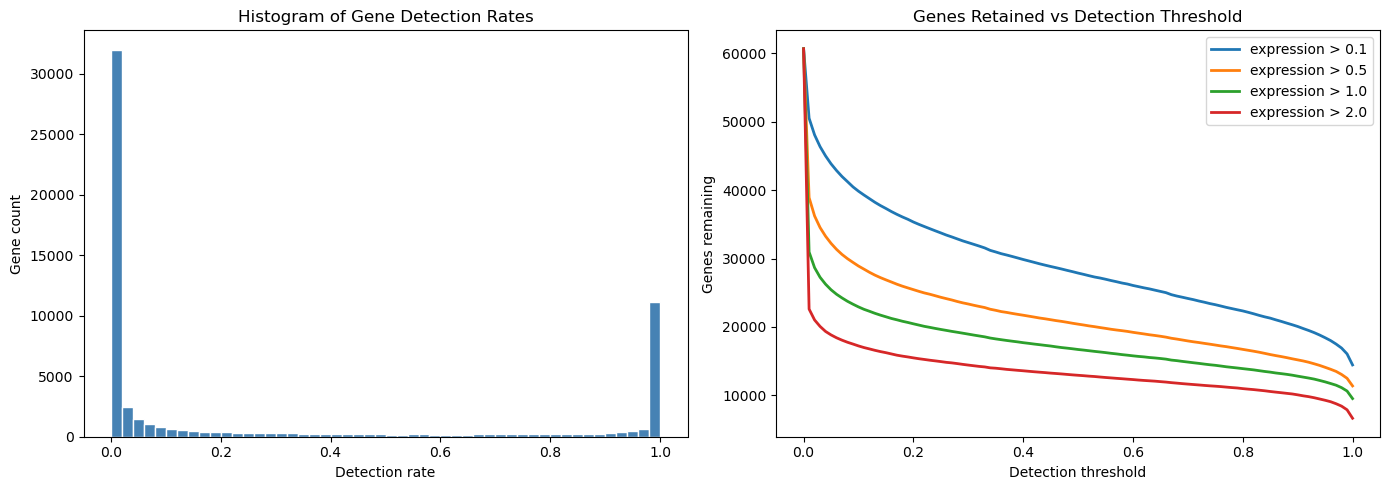

In [5]:
# Use train-only data to quantify how often each gene is detected across samples.

expression_thresholds = [0.1, 0.5, 1.0, 2.0]
detection_thresholds = np.linspace(0, 1, 101)

detection_rate_df = pd.DataFrame({
    f"detection_rate_tpm_gt_{threshold}": (X_train_df > threshold).sum(axis=0) / X_train_df.shape[0]
    for threshold in expression_thresholds
})

display(detection_rate_df.head(), detection_rate_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    detection_rate_df["detection_rate_tpm_gt_1.0"],
    bins=50,
    color="steelblue",
    edgecolor="white",
)
axes[0].set_title("Histogram of Gene Detection Rates")
axes[0].set_xlabel("Detection rate")
axes[0].set_ylabel("Gene count")

for threshold in expression_thresholds:
    col = f"detection_rate_tpm_gt_{threshold}"
    genes_retained = [(detection_rate_df[col] >= t).sum() for t in detection_thresholds]
    axes[1].plot(
        detection_thresholds,
        genes_retained,
        linewidth=2,
        label=f"expression > {threshold}",
    )

axes[1].set_title("Genes Retained vs Detection Threshold")
axes[1].set_xlabel("Detection threshold")
axes[1].set_ylabel("Genes remaining")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Evaluate low-expression filtering  
   - Explore thresholds for removing genes with consistently low expression.  
   - Assess impact on feature count and expression distribution.

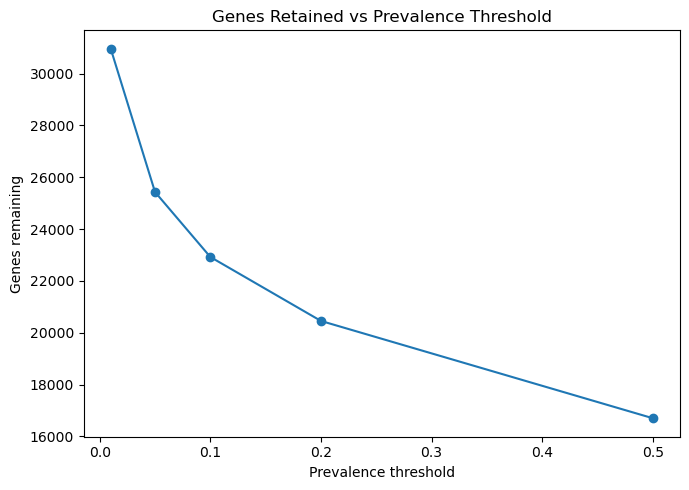

In [6]:
# Evaluate common prevalence thresholds to see how many genes would remain.

expression_threshold = 1.0 

detection_rate_df = pd.DataFrame({
    "detection_rate": (X_train_df > expression_threshold).sum(axis=0) / X_train_df.shape[0]
})

prevalence_thresholds = np.array([0.01, 0.05, 0.10, 0.20, 0.50])
genes_retained_df = pd.DataFrame({
    "prevalence_threshold": prevalence_thresholds,
    "genes_remaining": [(detection_rate_df["detection_rate"] >= t).sum() for t in prevalence_thresholds],
})

plt.figure(figsize=(7, 5))
plt.plot(genes_retained_df["prevalence_threshold"], genes_retained_df["genes_remaining"], marker="o")
plt.title("Genes Retained vs Prevalence Threshold")
plt.xlabel("Prevalence threshold")
plt.ylabel("Genes remaining")
plt.tight_layout()
plt.show()

In [7]:
# Define parameter thresholds for filtering genes based on expression and prevalence.

RNA_EXPRESSION_THRESHOLD = 1.0
RNA_PREVALENCE_THRESHOLD = 0.05

Genes before filtering: 60,660
Genes after filtering:  25,431


,mean_expression,median_expression,variance
Ensembl_ID,,,
ENSG00000000003.15,5.052530,5.064572,0.991125
ENSG00000000005.6,0.966997,0.636543,0.977202
ENSG00000000419.13,6.858716,6.796495,0.391257
ENSG00000000457.14,3.881653,3.918386,0.457295
ENSG00000000460.17,2.947533,2.937382,0.566260


,mean_expression,median_expression,variance
Ensembl_ID,,,
ENSG00000288605.1,0.378702,0.110764,0.391770
ENSG00000288612.1,1.430601,1.316204,0.327814
ENSG00000288658.1,0.482626,0.186881,0.536440
ENSG00000288670.1,3.852839,3.864018,0.453517
ENSG00000288675.1,0.971507,0.896466,0.199710


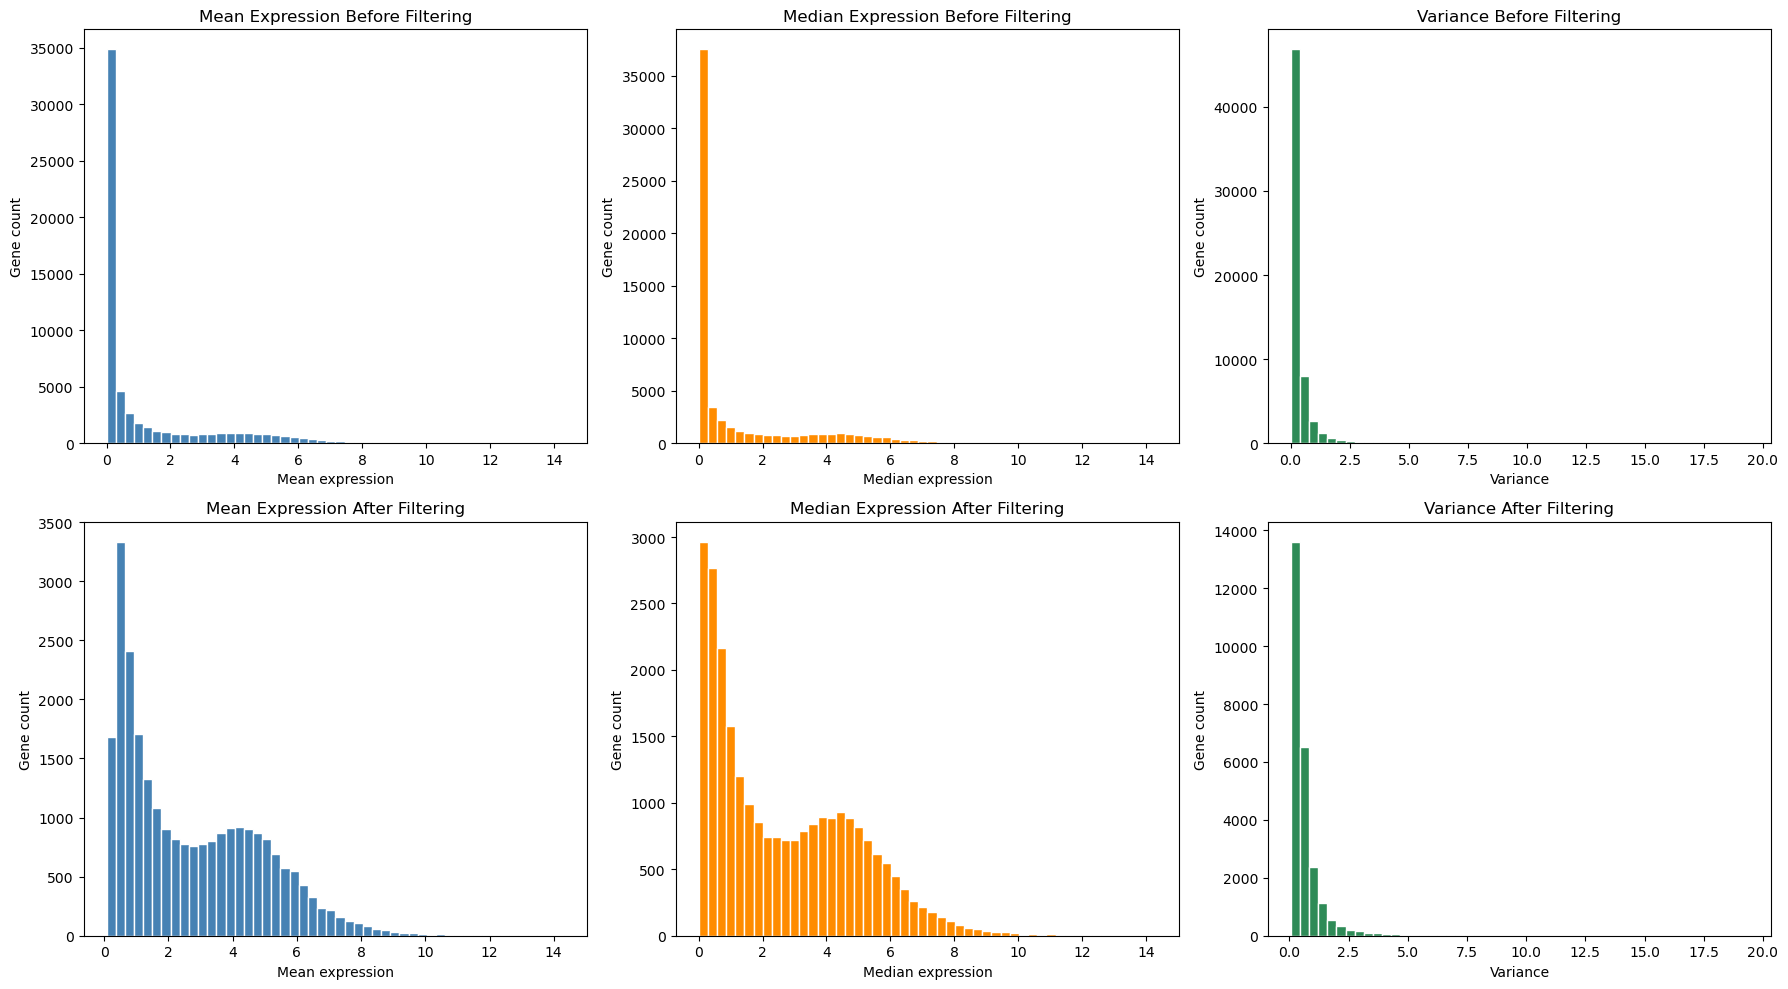

In [8]:
# Compare gene-level distributions before and after low-expression filtering on train only.

gene_detection_rate_df = pd.DataFrame({
    "detection_rate": (X_train_df > RNA_EXPRESSION_THRESHOLD).sum(axis=0) / X_train_df.shape[0]
})

retained_genes = gene_detection_rate_df.index[
    gene_detection_rate_df["detection_rate"] >= RNA_PREVALENCE_THRESHOLD
]

X_train_filtered_df = X_train_df.loc[:, retained_genes].copy()

gene_summary_before_df = pd.DataFrame({
    "mean_expression": X_train_df.mean(axis=0),
    "median_expression": X_train_df.median(axis=0),
    "variance": X_train_df.var(axis=0),
})

gene_summary_after_df = pd.DataFrame({
    "mean_expression": X_train_filtered_df.mean(axis=0),
    "median_expression": X_train_filtered_df.median(axis=0),
    "variance": X_train_filtered_df.var(axis=0),
})

print(f"Genes before filtering: {X_train_df.shape[1]:,}")
print(f"Genes after filtering:  {X_train_filtered_df.shape[1]:,}")
display(gene_summary_before_df.head(), gene_summary_after_df.tail())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(gene_summary_before_df["mean_expression"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Mean Expression Before Filtering")
axes[0, 0].set_xlabel("Mean expression")
axes[0, 0].set_ylabel("Gene count")

axes[0, 1].hist(gene_summary_before_df["median_expression"], bins=50, color="darkorange", edgecolor="white")
axes[0, 1].set_title("Median Expression Before Filtering")
axes[0, 1].set_xlabel("Median expression")
axes[0, 1].set_ylabel("Gene count")

axes[0, 2].hist(gene_summary_before_df["variance"], bins=50, color="seagreen", edgecolor="white")
axes[0, 2].set_title("Variance Before Filtering")
axes[0, 2].set_xlabel("Variance")
axes[0, 2].set_ylabel("Gene count")

axes[1, 0].hist(gene_summary_after_df["mean_expression"], bins=50, color="steelblue", edgecolor="white")
axes[1, 0].set_title("Mean Expression After Filtering")
axes[1, 0].set_xlabel("Mean expression")
axes[1, 0].set_ylabel("Gene count")

axes[1, 1].hist(gene_summary_after_df["median_expression"], bins=50, color="darkorange", edgecolor="white")
axes[1, 1].set_title("Median Expression After Filtering")
axes[1, 1].set_xlabel("Median expression")
axes[1, 1].set_ylabel("Gene count")

axes[1, 2].hist(gene_summary_after_df["variance"], bins=50, color="seagreen", edgecolor="white")
axes[1, 2].set_title("Variance After Filtering")
axes[1, 2].set_xlabel("Variance")
axes[1, 2].set_ylabel("Gene count")

plt.tight_layout()
plt.show()


## 5. Evaluate variance filtering  
   - Identify genes with near-zero variance across samples.  
   - Assess potential thresholds for removing uninformative genes.

,variance
Ensembl_ID,
ENSG00000000003.15,0.991125
ENSG00000000005.6,0.977202
ENSG00000000419.13,0.391257
ENSG00000000457.14,0.457295
ENSG00000000460.17,0.566260


,variance
Ensembl_ID,
ENSG00000288605.1,0.391770
ENSG00000288612.1,0.327814
ENSG00000288658.1,0.536440
ENSG00000288670.1,0.453517
ENSG00000288675.1,0.199710


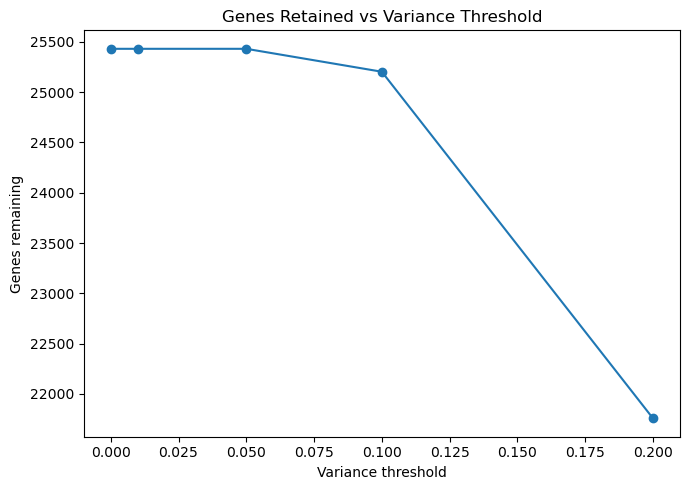

,variance_threshold,genes_remaining
0,0.00,25431
1,0.01,25431
2,0.05,25431
3,0.10,25203
4,0.20,21758


In [9]:
# Evaluate how many genes remain across simple variance thresholds.

gene_variance_df = pd.DataFrame({
    "variance": X_train_filtered_df.var(axis=0)
})

variance_thresholds = np.array([0.0, 0.01, 0.05, 0.10, 0.20])
genes_retained_df = pd.DataFrame({
    "variance_threshold": variance_thresholds,
    "genes_remaining": [(gene_variance_df["variance"] > t).sum() for t in variance_thresholds],
})

display(gene_variance_df.head(), gene_variance_df.tail())

plt.figure(figsize=(7, 5))
plt.plot(genes_retained_df["variance_threshold"], genes_retained_df["genes_remaining"], marker="o")
plt.title("Genes Retained vs Variance Threshold")
plt.xlabel("Variance threshold")
plt.ylabel("Genes remaining")
plt.tight_layout()
plt.show()

display(genes_retained_df)


### Variance filtering decision
- After low-expression filtering, very few genes exhibit near-zero variance across samples.
- Increasing the variance threshold has minimal effect on feature count until relatively large cutoffs.
- Therefore, we only remove constant genes (variance = 0) and do not apply additional variance filtering.

In [10]:
# Define parameter thresholds for filtering genes based on variance.

RNA_VARIANCE_THRESHOLD = 0

## 6. Assess scaling effects  
   - Evaluate the effect of standardization on expression features.  
   - Confirm scaling behavior across genes.

Gene-wise standardization centers features at zero and normalizes variance across genes.
Scaling will therefore be applied using a StandardScaler fit on the training set in the preprocessing pipeline.

,mean_before,mean_after,sd_before,sd_after
Ensembl_ID,,,,
ENSG00000000003.15,5.052530,1.312579e-17,0.995553,1.002472
ENSG00000000005.6,0.966997,-4.812789e-17,0.988535,1.002472
ENSG00000000419.13,6.858716,-2.596719e-15,0.625506,1.002472
ENSG00000000457.14,3.881653,-1.356332e-16,0.676236,1.002472
ENSG00000000460.17,2.947533,-1.881363e-16,0.752503,1.002472


,mean_before,mean_after,sd_before,sd_after
Ensembl_ID,,,,
ENSG00000288605.1,0.378702,1.531342e-17,0.625915,1.002472
ENSG00000288612.1,1.430601,7.437947e-16,0.572551,1.002472
ENSG00000288658.1,0.482626,0.000000e+00,0.732421,1.002472
ENSG00000288670.1,3.852839,-4.419016e-16,0.673437,1.002472
ENSG00000288675.1,0.971507,1.301641e-16,0.446890,1.002472


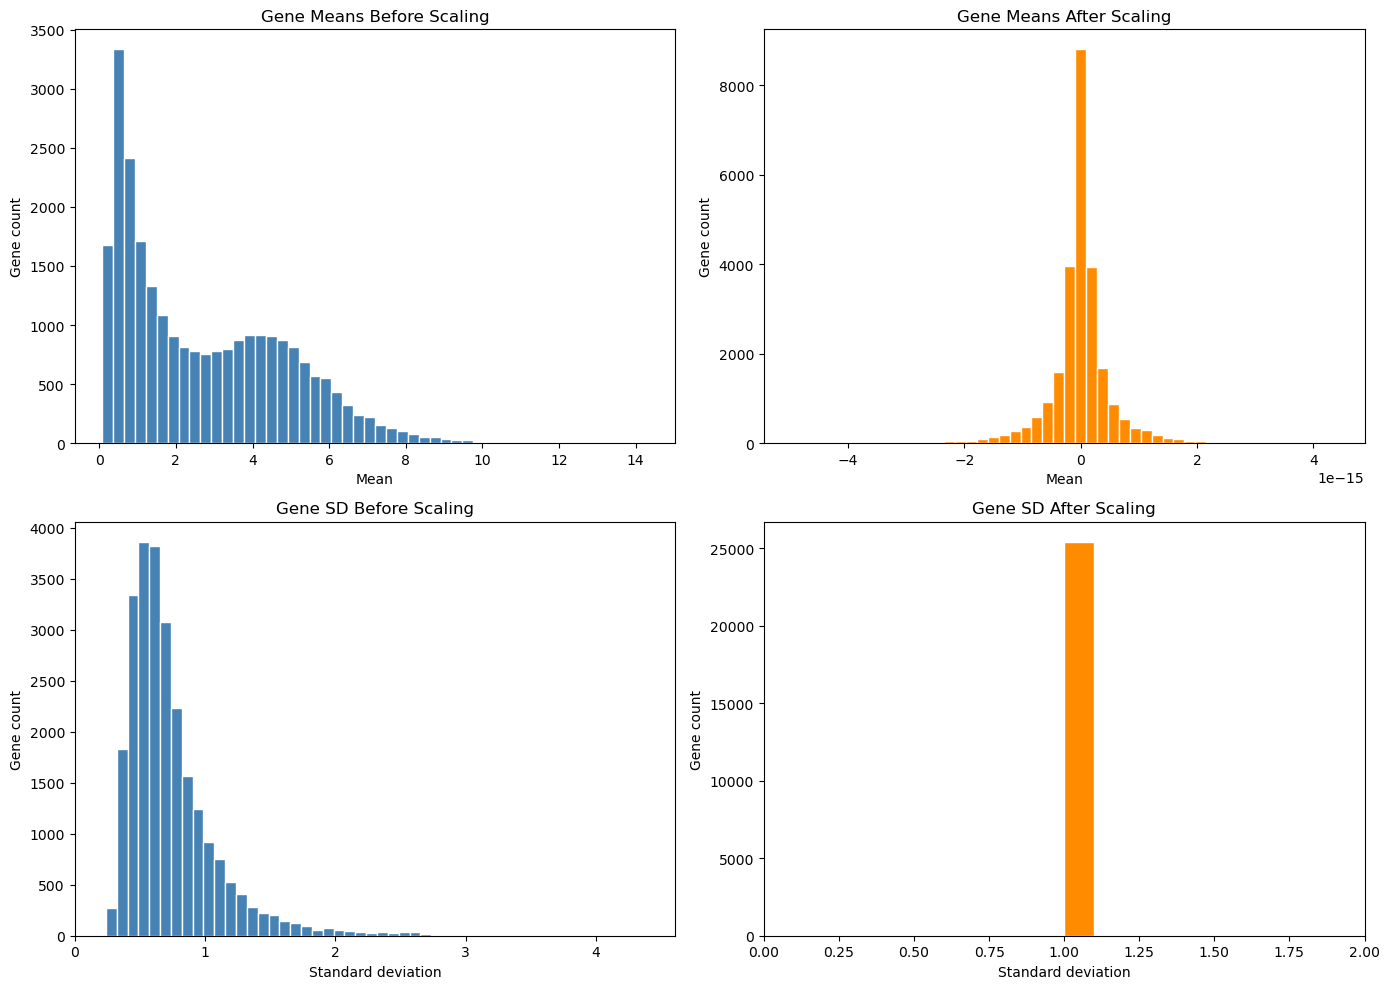

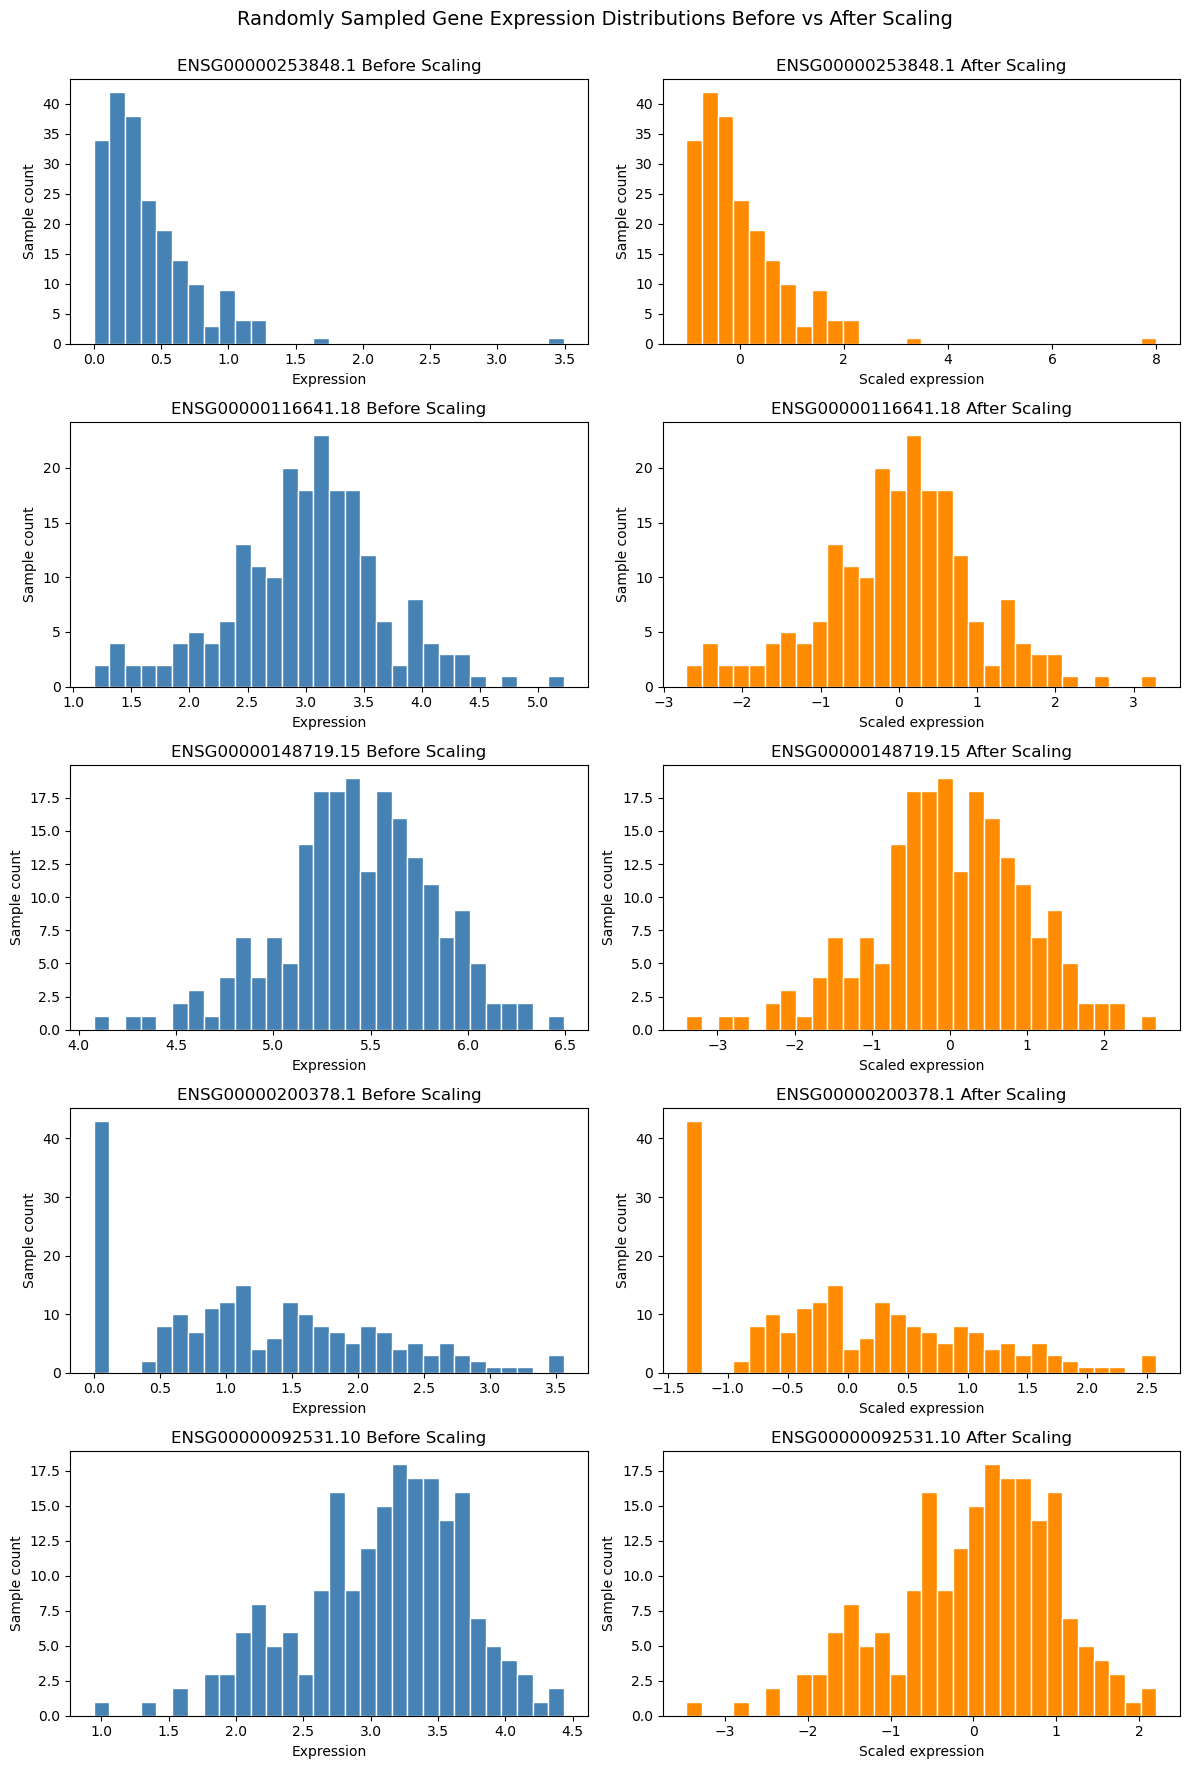

In [11]:
# Fit a prototype scaler on the filtered training data to inspect the effect of standardization.

scaler = StandardScaler()
X_train_scaled_array = scaler.fit_transform(X_train_filtered_df)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled_array,
    index=X_train_filtered_df.index,
    columns=X_train_filtered_df.columns,
)

gene_scaling_summary_df = pd.DataFrame({
    "mean_before": X_train_filtered_df.mean(axis=0),
    "mean_after": X_train_scaled_df.mean(axis=0),
    "sd_before": X_train_filtered_df.std(axis=0),
    "sd_after": X_train_scaled_df.std(axis=0),
})

display(gene_scaling_summary_df.head(), gene_scaling_summary_df.tail())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(gene_scaling_summary_df["mean_before"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Gene Means Before Scaling")
axes[0, 0].set_xlabel("Mean")
axes[0, 0].set_ylabel("Gene count")

axes[0, 1].hist(gene_scaling_summary_df["mean_after"], bins=50, color="darkorange", edgecolor="white")
axes[0, 1].set_title("Gene Means After Scaling")
axes[0, 1].set_xlabel("Mean")
axes[0, 1].set_ylabel("Gene count")

axes[1, 0].hist(gene_scaling_summary_df["sd_before"], bins=50, color="steelblue", edgecolor="white")
axes[1, 0].set_title("Gene SD Before Scaling")
axes[1, 0].set_xlabel("Standard deviation")
axes[1, 0].set_ylabel("Gene count")
axes[1, 0].set_xlim(left=0)

axes[1, 1].hist(gene_scaling_summary_df["sd_after"], bins=20, range=(0, 2), color="darkorange", edgecolor="white")
axes[1, 1].set_title("Gene SD After Scaling")
axes[1, 1].set_xlabel("Standard deviation")
axes[1, 1].set_ylabel("Gene count")
axes[1, 1].set_xlim(0, 2)

plt.tight_layout()
plt.show()

random_genes = pd.Series(X_train_filtered_df.columns).sample(n=5, random_state=42).tolist()

fig, axes = plt.subplots(5, 2, figsize=(12, 18))
fig.suptitle("Randomly Sampled Gene Expression Distributions Before vs After Scaling", fontsize=14)

for i, gene in enumerate(random_genes):
    axes[i, 0].hist(X_train_filtered_df[gene], bins=30, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"{gene} Before Scaling")
    axes[i, 0].set_xlabel("Expression")
    axes[i, 0].set_ylabel("Sample count")

    axes[i, 1].hist(X_train_scaled_df[gene], bins=30, color="darkorange", edgecolor="white")
    axes[i, 1].set_title(f"{gene} After Scaling")
    axes[i, 1].set_xlabel("Scaled expression")
    axes[i, 1].set_ylabel("Sample count")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## 7. Formalize and save preprocessing rules as JSON for downstream use.
   - Collect the defined parameters and save as JSON, also save enough metadata to make the rule file self-describing.

In [12]:
# Save the selected RNA preprocessing rules and a small amount of context for downstream use.

rna_preprocess_parameters = {
    "metadata": {
        "modality": "RNA-seq",
        "cohort": "TCGA-BRCA",
        "fit_split": "train",
        "input_unit": "TPM",
        "samples_as_rows": True,
        "genes_as_columns": True,
    },
    "parameters": {
        "RNA_EXPRESSION_THRESHOLD": RNA_EXPRESSION_THRESHOLD,
        "RNA_PREVALENCE_THRESHOLD": RNA_PREVALENCE_THRESHOLD,
        "RNA_VARIANCE_THRESHOLD": RNA_VARIANCE_THRESHOLD,
    },
    "artifacts": {
        "n_genes_before_filtering": int(X_train_df.shape[1]),
    },
}

params_path = Path("../data/interim/rna_preprocess_parameters.json")
params_path.parent.mkdir(parents=True, exist_ok=True)
params_path.write_text(json.dumps(rna_preprocess_parameters, indent=2), encoding="utf-8")

parameter_summary_df = pd.DataFrame({
    "parameter": [
        "RNA_EXPRESSION_THRESHOLD",
        "RNA_PREVALENCE_THRESHOLD",
        "RNA_VARIANCE_THRESHOLD",
    ],
    "value": [
        RNA_EXPRESSION_THRESHOLD,
        RNA_PREVALENCE_THRESHOLD,
        RNA_VARIANCE_THRESHOLD,
    ],
})

print(f"Saved RNA preprocessing parameters to {params_path}")
display(
    parameter_summary_df,
    pd.DataFrame({
        "artifact": ["n_genes_before_filtering"],
        "value": [X_train_df.shape[1]],
    }),
)


Saved RNA preprocessing parameters to ../data/interim/rna_preprocess_parameters.json


,parameter,value
0,RNA_EXPRESSION_THRESHOLD,1.00
1,RNA_PREVALENCE_THRESHOLD,0.05
2,RNA_VARIANCE_THRESHOLD,0.00


,artifact,value
0,n_genes_before_filtering,60660


## 8. Fit preprocessing parameters on the training set only  
   - Compute filtering thresholds and scaling parameters using `X_train`.

In [13]:
# Load saved RNA preprocessing rules, then fit train-only filtering and scaling parameters.

params_path = Path("../data/interim/rna_preprocess_parameters.json")
rna_preprocess_parameters = json.loads(params_path.read_text(encoding="utf-8"))

RNA_EXPRESSION_THRESHOLD = rna_preprocess_parameters["parameters"]["RNA_EXPRESSION_THRESHOLD"]
RNA_PREVALENCE_THRESHOLD = rna_preprocess_parameters["parameters"]["RNA_PREVALENCE_THRESHOLD"]
RNA_VARIANCE_THRESHOLD = rna_preprocess_parameters["parameters"]["RNA_VARIANCE_THRESHOLD"]

gene_detection_rate_df = pd.DataFrame({
    "detection_rate": (X_train_df > RNA_EXPRESSION_THRESHOLD).sum(axis=0) / X_train_df.shape[0]
})

genes_after_prevalence_filter = gene_detection_rate_df.index[
    gene_detection_rate_df["detection_rate"] >= RNA_PREVALENCE_THRESHOLD
].tolist()

X_train_prevalence_filtered_df = X_train_df.loc[:, genes_after_prevalence_filter].copy()

gene_variance_df = pd.DataFrame({
    "variance": X_train_prevalence_filtered_df.var(axis=0)
})

RNA_FINAL_GENE_LIST = gene_variance_df.index[
    gene_variance_df["variance"] > RNA_VARIANCE_THRESHOLD
].tolist()

X_train_filtered_df = X_train_df.loc[:, RNA_FINAL_GENE_LIST].copy()

scaler = StandardScaler().fit(X_train_filtered_df)
RNA_SCALER_GENE_MEANS = pd.Series(scaler.mean_, index=X_train_filtered_df.columns, name="mean")
RNA_SCALER_GENE_STDS = pd.Series(scaler.scale_, index=X_train_filtered_df.columns, name="std")

print(f"Genes prior to filters: {len(X_train_df.columns):,}")
print(f"Genes after prevalence filter: {len(genes_after_prevalence_filter):,}")
print(f"Genes after variance filter:   {len(RNA_FINAL_GENE_LIST):,}")

display(
    gene_detection_rate_df.head(),
    gene_variance_df.head(),
)


Genes prior to filters: 60,660
Genes after prevalence filter: 25,431
Genes after variance filter:   25,431


,detection_rate
Ensembl_ID,
ENSG00000000003.15,1.000000
ENSG00000000005.6,0.364532
ENSG00000000419.13,1.000000
ENSG00000000457.14,1.000000
ENSG00000000460.17,0.995074


,variance
Ensembl_ID,
ENSG00000000003.15,0.991125
ENSG00000000005.6,0.977202
ENSG00000000419.13,0.391257
ENSG00000000457.14,0.457295
ENSG00000000460.17,0.566260


In [14]:
def fit_rna_preprocessing_parameters(
    X_train_df: pd.DataFrame,
    params_path: str | Path,
) -> list[str]:
    """Load saved RNA preprocessing rules and fit the final training-derived gene list.

    Parameters:
    - X_train_df: training RNA expression dataframe with samples as rows and genes as columns
    - params_path: path to the saved RNA preprocessing parameter JSON

    Returns:
    - RNA_FINAL_GENE_LIST: genes retained after prevalence and variance filtering
    """
    if X_train_df.empty:
        raise ValueError("X_train_df is empty")

    params_path = Path(params_path)
    rna_preprocess_parameters = json.loads(params_path.read_text(encoding="utf-8"))

    RNA_EXPRESSION_THRESHOLD = rna_preprocess_parameters["parameters"]["RNA_EXPRESSION_THRESHOLD"]
    RNA_PREVALENCE_THRESHOLD = rna_preprocess_parameters["parameters"]["RNA_PREVALENCE_THRESHOLD"]
    RNA_VARIANCE_THRESHOLD = rna_preprocess_parameters["parameters"]["RNA_VARIANCE_THRESHOLD"]

    gene_detection_rate_df = pd.DataFrame({
        "detection_rate": (X_train_df > RNA_EXPRESSION_THRESHOLD).sum(axis=0) / X_train_df.shape[0]
    })

    genes_after_prevalence_filter = gene_detection_rate_df.index[
        gene_detection_rate_df["detection_rate"] >= RNA_PREVALENCE_THRESHOLD
    ].tolist()

    X_train_prevalence_filtered_df = X_train_df.loc[:, genes_after_prevalence_filter].copy()

    gene_variance_df = pd.DataFrame({
        "variance": X_train_prevalence_filtered_df.var(axis=0)
    })

    RNA_FINAL_GENE_LIST = gene_variance_df.index[
        gene_variance_df["variance"] > RNA_VARIANCE_THRESHOLD
    ].tolist()

    return RNA_FINAL_GENE_LIST

RNA_FINAL_GENE_LIST_fn = fit_rna_preprocessing_parameters(
    X_train_df=X_train_df,
    params_path="../data/interim/rna_preprocess_parameters.json",
)

assert RNA_FINAL_GENE_LIST_fn == RNA_FINAL_GENE_LIST
print("Refactored function matches the original notebook output.")


Refactored function matches the original notebook output.


## 9. Apply preprocessing to all splits  
   - Transform train, validation, and test using parameters learned from the training set.

In [15]:
# Apply the training-derived gene list and fitted scaler to all splits without refitting.

missing_genes_df = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n_missing_genes": [
        len(set(RNA_FINAL_GENE_LIST) - set(X_train_df.columns)),
        len(set(RNA_FINAL_GENE_LIST) - set(X_val_df.columns)),
        len(set(RNA_FINAL_GENE_LIST) - set(X_test_df.columns)),
    ],
})

if (missing_genes_df["n_missing_genes"] > 0).any():
    raise ValueError("Some training-selected genes are missing from one or more splits")

X_train_filtered_df = X_train_df.loc[:, RNA_FINAL_GENE_LIST].copy()
X_val_filtered_df = X_val_df.loc[:, RNA_FINAL_GENE_LIST].copy()
X_test_filtered_df = X_test_df.loc[:, RNA_FINAL_GENE_LIST].copy()

# Transform all splits using the scaler fit on X_train only, while preserving feature order.
X_train_scaled_df = pd.DataFrame(
    scaler.transform(X_train_filtered_df),
    index=X_train_filtered_df.index,
    columns=RNA_FINAL_GENE_LIST,
)
X_val_scaled_df = pd.DataFrame(
    scaler.transform(X_val_filtered_df),
    index=X_val_filtered_df.index,
    columns=RNA_FINAL_GENE_LIST,
)
X_test_scaled_df = pd.DataFrame(
    scaler.transform(X_test_filtered_df),
    index=X_test_filtered_df.index,
    columns=RNA_FINAL_GENE_LIST,
)

print(f"train: {X_train_scaled_df.shape}")
print(f"val:   {X_val_scaled_df.shape}")
print(f"test:  {X_test_scaled_df.shape}")
display(X_test_scaled_df.head(), X_test_scaled_df.tail())

train: (203, 25431)
val:   (43, 25431)
test:  (44, 25431)


,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288573.1,ENSG00000288585.1,ENSG00000288586.1,ENSG00000288596.2,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288670.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-GM-A3XN-01A,-0.199096,3.217656,-0.800997,-0.381368,-0.428472,1.109594,0.683812,-1.590599,-0.776381,-1.594189,...,0.814557,-0.540881,0.443113,1.000522,0.326776,0.196863,1.553278,-0.523655,-0.497624,1.048776
TCGA-BH-A0DT-01A,1.418355,0.457663,-0.390965,1.213761,0.498321,0.244278,0.905438,0.041881,0.415086,0.672114,...,0.113054,0.355884,-0.669740,0.417129,0.008571,-0.379803,-0.009472,-0.563480,0.603240,-0.042675
TCGA-BH-A0B5-01A,0.401976,-0.352342,-0.252554,1.595214,2.132846,0.734293,0.159983,-0.923746,-0.721907,0.568143,...,0.689755,2.121745,0.080499,1.194569,0.452270,-0.125570,0.985371,-0.660575,0.444405,-0.408422
TCGA-B6-A0WX-01A,0.905436,-0.868034,0.202728,-0.350857,0.862692,-0.963469,0.222776,0.859266,-0.391718,0.148904,...,-0.786893,-0.176582,0.051864,1.369993,-0.646801,1.373405,0.247858,-0.085315,1.500868,-0.020177
TCGA-BH-A0C1-01B,2.086015,-0.514403,-0.086896,1.849713,2.013551,-0.134729,1.027556,0.435991,0.092675,2.022511,...,-2.138214,1.834114,-0.132094,-0.215564,0.616276,-0.329865,-0.745864,0.126994,2.220036,0.046393


,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288573.1,ENSG00000288585.1,ENSG00000288586.1,ENSG00000288596.2,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288670.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AR-A2LJ-01A,-0.294084,1.261301,-1.406074,-1.672663,-1.034167,1.946315,-0.774806,-0.361826,-1.065749,-1.852542,...,0.262270,-0.792594,-0.268780,-1.023492,0.205281,-0.433630,0.507040,-0.381166,-1.095245,0.233506
TCGA-BH-A1FU-01A,1.031183,-0.762730,-0.794597,-0.043574,0.222964,-0.164332,0.919060,-0.557669,1.771232,1.523512,...,-0.478145,-0.128398,-1.218747,-0.433517,-0.237042,-0.221154,-0.711850,-0.558036,-0.788657,1.868235
TCGA-BH-A18V-01A,-0.950769,0.103734,1.260460,0.035331,2.120926,0.886852,0.486768,-0.754932,0.768866,1.253246,...,1.212878,-0.441253,-0.173654,1.514320,-0.326767,4.082634,0.021192,-0.488414,1.493488,1.514539
TCGA-AR-A2LL-01A,-0.047584,-0.551244,-0.029169,0.740595,0.505172,2.013236,-0.804065,0.183801,1.066354,1.615179,...,0.838250,1.948481,2.128246,2.454483,-0.629613,-0.540702,1.572961,-0.461631,0.635324,-0.584648
TCGA-AR-A5QQ-01A,-0.274815,-0.670287,0.377510,-2.735980,-0.300704,1.016432,0.213283,-0.099146,-1.436610,-1.779362,...,0.230075,-0.862041,-0.193979,-1.920920,1.894187,-0.533751,-0.326443,-0.441029,-1.658461,2.125771


In [16]:
# Apply the training-derived gene list and fitted scaler to all splits without refitting.

def apply_rna_preprocessing_to_splits(
    X_train_df: pd.DataFrame,
    X_val_df: pd.DataFrame,
    X_test_df: pd.DataFrame,
    RNA_FINAL_GENE_LIST: list[str],
    scaler: StandardScaler,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Apply the training-derived gene list and fitted scaler to train, validation, and test splits.

    Parameters:
    - X_train_df: training RNA dataframe with samples as rows and genes as columns
    - X_val_df: validation RNA dataframe with samples as rows and genes as columns
    - X_test_df: test RNA dataframe with samples as rows and genes as columns
    - RNA_FINAL_GENE_LIST: training-derived final gene list to retain in all splits
    - scaler: StandardScaler fit on the training split only

    Returns:
    - X_train_scaled_df: filtered and scaled training dataframe
    - X_val_scaled_df: filtered and scaled validation dataframe
    - X_test_scaled_df: filtered and scaled test dataframe
    """
    missing_genes_df = pd.DataFrame({
        "split": ["train", "val", "test"],
        "n_missing_genes": [
            len(set(RNA_FINAL_GENE_LIST) - set(X_train_df.columns)),
            len(set(RNA_FINAL_GENE_LIST) - set(X_val_df.columns)),
            len(set(RNA_FINAL_GENE_LIST) - set(X_test_df.columns)),
        ],
    })

    if (missing_genes_df["n_missing_genes"] > 0).any():
        raise ValueError("Some training-selected genes are missing from one or more splits")

    X_train_filtered_df = X_train_df.loc[:, RNA_FINAL_GENE_LIST].copy()
    X_val_filtered_df = X_val_df.loc[:, RNA_FINAL_GENE_LIST].copy()
    X_test_filtered_df = X_test_df.loc[:, RNA_FINAL_GENE_LIST].copy()

    X_train_scaled_df = pd.DataFrame(
        scaler.transform(X_train_filtered_df),
        index=X_train_filtered_df.index,
        columns=RNA_FINAL_GENE_LIST,
    )
    X_val_scaled_df = pd.DataFrame(
        scaler.transform(X_val_filtered_df),
        index=X_val_filtered_df.index,
        columns=RNA_FINAL_GENE_LIST,
    )
    X_test_scaled_df = pd.DataFrame(
        scaler.transform(X_test_filtered_df),
        index=X_test_filtered_df.index,
        columns=RNA_FINAL_GENE_LIST,
    )

    print(f"train: {X_train_scaled_df.shape}")
    print(f"val:   {X_val_scaled_df.shape}")
    print(f"test:  {X_test_scaled_df.shape}")
    display(X_train_scaled_df.head(), X_test_scaled_df.tail())

    return X_train_scaled_df, X_val_scaled_df, X_test_scaled_df


X_train_scaled_df_fn, X_val_scaled_df_fn, X_test_scaled_df_fn = apply_rna_preprocessing_to_splits(
    X_train_df=X_train_df,
    X_val_df=X_val_df,
    X_test_df=X_test_df,
    RNA_FINAL_GENE_LIST=RNA_FINAL_GENE_LIST,
    scaler=scaler,
)

assert X_train_scaled_df_fn.shape == X_train_scaled_df.shape
assert X_val_scaled_df_fn.shape == X_val_scaled_df.shape
assert X_test_scaled_df_fn.shape == X_test_scaled_df.shape

assert X_train_scaled_df_fn.index.equals(X_train_scaled_df.index)
assert X_val_scaled_df_fn.index.equals(X_val_scaled_df.index)
assert X_test_scaled_df_fn.index.equals(X_test_scaled_df.index)

assert X_train_scaled_df_fn.columns.equals(X_train_scaled_df.columns)
assert X_val_scaled_df_fn.columns.equals(X_val_scaled_df.columns)
assert X_test_scaled_df_fn.columns.equals(X_test_scaled_df.columns)

assert np.allclose(X_train_scaled_df_fn.values, X_train_scaled_df.values)
assert np.allclose(X_val_scaled_df_fn.values, X_val_scaled_df.values)
assert np.allclose(X_test_scaled_df_fn.values, X_test_scaled_df.values)

print("Refactored function matches the original notebook outputs.")


train: (203, 25431)
val:   (43, 25431)
test:  (44, 25431)


,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288573.1,ENSG00000288585.1,ENSG00000288586.1,ENSG00000288596.2,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288670.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AR-A1AN-01A,-0.921931,0.378658,-1.174161,-0.611187,-0.610914,-0.249239,0.837047,0.323434,0.456512,-0.088932,...,-1.353641,-0.352161,0.247873,-1.847424,-0.651507,-0.606533,-0.440411,0.176202,0.426529,1.225862
TCGA-B6-A2IU-01A,-0.972194,0.665513,-1.350524,2.081968,0.961827,-0.919410,-0.874112,-1.378494,0.926571,0.534901,...,0.012429,1.103978,1.517371,0.609031,0.524253,-0.474512,-0.202529,-0.660575,0.394027,-0.961233
TCGA-C8-A12Q-01A,0.091865,0.330616,0.620092,0.676719,0.367927,0.586679,0.679828,-0.486117,0.479864,-0.354779,...,-1.509343,-0.020435,-0.527875,-0.585608,0.204504,-0.378965,2.682691,-0.551112,0.489490,-1.008443
TCGA-BH-A0E9-01B,1.720857,0.423156,-0.174513,1.528813,1.259411,0.227238,1.043159,0.209277,0.017179,0.802620,...,0.585732,2.531337,-0.092806,0.688908,-0.607627,-0.034685,1.212378,-0.406525,0.965263,0.145407
TCGA-A2-A0ST-01A,0.243425,-0.114109,-0.919132,-1.255508,-0.481986,1.644299,-0.028138,-0.191235,-1.162009,-0.118621,...,0.178092,-0.914768,-1.051409,-0.765611,2.093778,-0.025683,-0.928029,0.542307,-1.556974,-0.272568


,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288573.1,ENSG00000288585.1,ENSG00000288586.1,ENSG00000288596.2,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288670.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AR-A2LJ-01A,-0.294084,1.261301,-1.406074,-1.672663,-1.034167,1.946315,-0.774806,-0.361826,-1.065749,-1.852542,...,0.262270,-0.792594,-0.268780,-1.023492,0.205281,-0.433630,0.507040,-0.381166,-1.095245,0.233506
TCGA-BH-A1FU-01A,1.031183,-0.762730,-0.794597,-0.043574,0.222964,-0.164332,0.919060,-0.557669,1.771232,1.523512,...,-0.478145,-0.128398,-1.218747,-0.433517,-0.237042,-0.221154,-0.711850,-0.558036,-0.788657,1.868235
TCGA-BH-A18V-01A,-0.950769,0.103734,1.260460,0.035331,2.120926,0.886852,0.486768,-0.754932,0.768866,1.253246,...,1.212878,-0.441253,-0.173654,1.514320,-0.326767,4.082634,0.021192,-0.488414,1.493488,1.514539
TCGA-AR-A2LL-01A,-0.047584,-0.551244,-0.029169,0.740595,0.505172,2.013236,-0.804065,0.183801,1.066354,1.615179,...,0.838250,1.948481,2.128246,2.454483,-0.629613,-0.540702,1.572961,-0.461631,0.635324,-0.584648
TCGA-AR-A5QQ-01A,-0.274815,-0.670287,0.377510,-2.735980,-0.300704,1.016432,0.213283,-0.099146,-1.436610,-1.779362,...,0.230075,-0.862041,-0.193979,-1.920920,1.894187,-0.533751,-0.326443,-0.441029,-1.658461,2.125771


Refactored function matches the original notebook outputs.


## 10. Validate outputs  
   - Confirm expected feature counts after filtering  
   - Verify row counts match split sizes  
   - Verify no ID drift or leakage

In [17]:
# Check split sizes, feature counts, and sample ID alignment after applying train-fit preprocessing.

expected_feature_count = len(RNA_FINAL_GENE_LIST)

validation_summary_df = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n_rows": [X_train_scaled_df.shape[0], X_val_scaled_df.shape[0], X_test_scaled_df.shape[0]],
    "expected_rows": [len(train_ids), len(val_ids), len(test_ids)],
    "n_features": [X_train_scaled_df.shape[1], X_val_scaled_df.shape[1], X_test_scaled_df.shape[1]],
    "expected_features": [expected_feature_count, expected_feature_count, expected_feature_count],
})

if not (validation_summary_df["n_rows"] == validation_summary_df["expected_rows"]).all():
    raise ValueError("Row counts do not match saved split sizes")

if not (validation_summary_df["n_features"] == validation_summary_df["expected_features"]).all():
    raise ValueError("Feature counts do not match the final training-derived gene list")

if list(X_train_scaled_df.index.astype(str)) != list(train_ids.astype(str)):
    raise ValueError("Train sample IDs do not match saved split order")
if list(X_val_scaled_df.index.astype(str)) != list(val_ids.astype(str)):
    raise ValueError("Validation sample IDs do not match saved split order")
if list(X_test_scaled_df.index.astype(str)) != list(test_ids.astype(str)):
    raise ValueError("Test sample IDs do not match saved split order")

train_id_set = set(X_train_scaled_df.index.astype(str))
val_id_set = set(X_val_scaled_df.index.astype(str))
test_id_set = set(X_test_scaled_df.index.astype(str))

if not train_id_set.isdisjoint(val_id_set):
    raise ValueError("Leakage detected between train and val")
if not train_id_set.isdisjoint(test_id_set):
    raise ValueError("Leakage detected between train and test")
if not val_id_set.isdisjoint(test_id_set):
    raise ValueError("Leakage detected between val and test")

print("All RNA preprocessing validation checks passed.")
display(validation_summary_df)


All RNA preprocessing validation checks passed.


,split,n_rows,expected_rows,n_features,expected_features
0,train,203,203,25431,25431
1,val,43,43,25431,25431
2,test,44,44,25431,25431


In [18]:
# Check split sizes, feature counts, and sample ID alignment after applying train-fit preprocessing.

def validate_rna_preprocessing_outputs(
    X_train_scaled_df: pd.DataFrame,
    X_val_scaled_df: pd.DataFrame,
    X_test_scaled_df: pd.DataFrame,
    train_ids: pd.Series,
    val_ids: pd.Series,
    test_ids: pd.Series,
    RNA_FINAL_GENE_LIST: list[str],
) -> pd.DataFrame:
    """Validate RNA preprocessing outputs for feature count, split size, and ID integrity.

    Parameters:
    - X_train_scaled_df: processed training RNA dataframe
    - X_val_scaled_df: processed validation RNA dataframe
    - X_test_scaled_df: processed test RNA dataframe
    - train_ids: saved training sample IDs
    - val_ids: saved validation sample IDs
    - test_ids: saved test sample IDs
    - RNA_FINAL_GENE_LIST: final training-derived gene list

    Returns:
    - validation_summary_df: summary dataframe of row and feature count checks
    """
    expected_feature_count = len(RNA_FINAL_GENE_LIST)

    validation_summary_df = pd.DataFrame({
        "split": ["train", "val", "test"],
        "n_rows": [X_train_scaled_df.shape[0], X_val_scaled_df.shape[0], X_test_scaled_df.shape[0]],
        "expected_rows": [len(train_ids), len(val_ids), len(test_ids)],
        "n_features": [X_train_scaled_df.shape[1], X_val_scaled_df.shape[1], X_test_scaled_df.shape[1]],
        "expected_features": [expected_feature_count, expected_feature_count, expected_feature_count],
    })

    if not (validation_summary_df["n_rows"] == validation_summary_df["expected_rows"]).all():
        raise ValueError("Row counts do not match saved split sizes")

    if not (validation_summary_df["n_features"] == validation_summary_df["expected_features"]).all():
        raise ValueError("Feature counts do not match the final training-derived gene list")

    if list(X_train_scaled_df.index.astype(str)) != list(train_ids.astype(str)):
        raise ValueError("Train sample IDs do not match saved split order")
    if list(X_val_scaled_df.index.astype(str)) != list(val_ids.astype(str)):
        raise ValueError("Validation sample IDs do not match saved split order")
    if list(X_test_scaled_df.index.astype(str)) != list(test_ids.astype(str)):
        raise ValueError("Test sample IDs do not match saved split order")

    train_id_set = set(X_train_scaled_df.index.astype(str))
    val_id_set = set(X_val_scaled_df.index.astype(str))
    test_id_set = set(X_test_scaled_df.index.astype(str))

    if not train_id_set.isdisjoint(val_id_set):
        raise ValueError("Leakage detected between train and val")
    if not train_id_set.isdisjoint(test_id_set):
        raise ValueError("Leakage detected between train and test")
    if not val_id_set.isdisjoint(test_id_set):
        raise ValueError("Leakage detected between val and test")

    print("All RNA preprocessing validation checks passed.")
    display(validation_summary_df)

    return validation_summary_df


validation_summary_df_fn = validate_rna_preprocessing_outputs(
    X_train_scaled_df=X_train_scaled_df,
    X_val_scaled_df=X_val_scaled_df,
    X_test_scaled_df=X_test_scaled_df,
    train_ids=train_ids,
    val_ids=val_ids,
    test_ids=test_ids,
    RNA_FINAL_GENE_LIST=RNA_FINAL_GENE_LIST,
)

assert validation_summary_df_fn.equals(validation_summary_df)
print("Refactored function matches the original notebook outputs.")

All RNA preprocessing validation checks passed.


,split,n_rows,expected_rows,n_features,expected_features
0,train,203,203,25431,25431
1,val,43,43,25431,25431
2,test,44,44,25431,25431


Refactored function matches the original notebook outputs.


## 11. Test preprocessing module

In [19]:
# Run the RNA preprocessing module through its CLI entry point.

result = subprocess.run(
    [
        "python",
        "../scripts/preprocess_rna.py",
        "--rna-path",
        "../data/raw/TCGA-BRCA.star_tpm.tsv.gz",
        "--sample-ids-path",
        "../data/interim/sample_ids_cohort.csv",
        "--params-path",
        "../data/interim/rna_preprocess_parameters.json",
        "--split-dir",
        "../data/processed/splits/os_seed42_v15_t15",
        "--outdir",
        "../data/processed/rna",
    ],
    capture_output=True,
    text=True,
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"preprocess_rna.py failed with exit code {result.returncode}")

# Load saved outputs and compare them to the notebook-derived objects.
train_parquet_path = Path("../data/processed/rna/train/X_rna.parquet")
val_parquet_path = Path("../data/processed/rna/val/X_rna.parquet")
test_parquet_path = Path("../data/processed/rna/test/X_rna.parquet")
metadata_path = Path("../data/processed/rna/rna_preprocess_metadata.json")

X_train_scaled_cli_df = pd.read_parquet(train_parquet_path)
X_val_scaled_cli_df = pd.read_parquet(val_parquet_path)
X_test_scaled_cli_df = pd.read_parquet(test_parquet_path)
rna_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

# Check split shapes, feature counts, and feature order.
assert X_train_scaled_cli_df.shape == X_train_scaled_df.shape
assert X_val_scaled_cli_df.shape == X_val_scaled_df.shape
assert X_test_scaled_cli_df.shape == X_test_scaled_df.shape

assert X_train_scaled_cli_df.columns.equals(X_train_scaled_df.columns)
assert X_val_scaled_cli_df.columns.equals(X_val_scaled_df.columns)
assert X_test_scaled_cli_df.columns.equals(X_test_scaled_df.columns)

assert X_train_scaled_cli_df.index.equals(X_train_scaled_df.index)
assert X_val_scaled_cli_df.index.equals(X_val_scaled_df.index)
assert X_test_scaled_cli_df.index.equals(X_test_scaled_df.index)

assert np.allclose(X_train_scaled_cli_df.values, X_train_scaled_df.values)
assert np.allclose(X_val_scaled_cli_df.values, X_val_scaled_df.values)
assert np.allclose(X_test_scaled_cli_df.values, X_test_scaled_df.values)

# Check a few key metadata values recorded by the pipeline run.
assert rna_metadata["script_name"] == "preprocess_rna.py"
assert rna_metadata["config_path"].endswith("data/interim/rna_preprocess_parameters.json")
assert rna_metadata["key_parameters_used"]["RNA_EXPRESSION_THRESHOLD"] == RNA_EXPRESSION_THRESHOLD
assert rna_metadata["key_parameters_used"]["RNA_PREVALENCE_THRESHOLD"] == RNA_PREVALENCE_THRESHOLD
assert rna_metadata["key_parameters_used"]["RNA_VARIANCE_THRESHOLD"] == RNA_VARIANCE_THRESHOLD

assert rna_metadata["dataset_statistics"]["n_samples_train"] == X_train_scaled_df.shape[0]
assert rna_metadata["dataset_statistics"]["n_samples_val"] == X_val_scaled_df.shape[0]
assert rna_metadata["dataset_statistics"]["n_samples_test"] == X_test_scaled_df.shape[0]
assert rna_metadata["dataset_statistics"]["n_features_after_filtering"] == X_train_scaled_df.shape[1]

display(X_train_scaled_cli_df.head(), X_test_scaled_cli_df.tail())
display(pd.DataFrame(rna_metadata["validation_summary"]))


,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288573.1,ENSG00000288585.1,ENSG00000288586.1,ENSG00000288596.2,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288670.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AR-A1AN-01A,-0.921931,0.378658,-1.174161,-0.611187,-0.610914,-0.249239,0.837047,0.323434,0.456512,-0.088932,...,-1.353641,-0.352161,0.247873,-1.847424,-0.651507,-0.606533,-0.440411,0.176202,0.426529,1.225862
TCGA-B6-A2IU-01A,-0.972194,0.665513,-1.350524,2.081968,0.961827,-0.919410,-0.874112,-1.378494,0.926571,0.534901,...,0.012429,1.103978,1.517371,0.609031,0.524253,-0.474512,-0.202529,-0.660575,0.394027,-0.961233
TCGA-C8-A12Q-01A,0.091865,0.330616,0.620092,0.676719,0.367927,0.586679,0.679828,-0.486117,0.479864,-0.354779,...,-1.509343,-0.020435,-0.527875,-0.585608,0.204504,-0.378965,2.682691,-0.551112,0.489490,-1.008443
TCGA-BH-A0E9-01B,1.720857,0.423156,-0.174513,1.528813,1.259411,0.227238,1.043159,0.209277,0.017179,0.802620,...,0.585732,2.531337,-0.092806,0.688908,-0.607627,-0.034685,1.212378,-0.406525,0.965263,0.145407
TCGA-A2-A0ST-01A,0.243425,-0.114109,-0.919132,-1.255508,-0.481986,1.644299,-0.028138,-0.191235,-1.162009,-0.118621,...,0.178092,-0.914768,-1.051409,-0.765611,2.093778,-0.025683,-0.928029,0.542307,-1.556974,-0.272568


,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288573.1,ENSG00000288585.1,ENSG00000288586.1,ENSG00000288596.2,ENSG00000288600.1,ENSG00000288605.1,ENSG00000288612.1,ENSG00000288658.1,ENSG00000288670.1,ENSG00000288675.1
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AR-A2LJ-01A,-0.294084,1.261301,-1.406074,-1.672663,-1.034167,1.946315,-0.774806,-0.361826,-1.065749,-1.852542,...,0.262270,-0.792594,-0.268780,-1.023492,0.205281,-0.433630,0.507040,-0.381166,-1.095245,0.233506
TCGA-BH-A1FU-01A,1.031183,-0.762730,-0.794597,-0.043574,0.222964,-0.164332,0.919060,-0.557669,1.771232,1.523512,...,-0.478145,-0.128398,-1.218747,-0.433517,-0.237042,-0.221154,-0.711850,-0.558036,-0.788657,1.868235
TCGA-BH-A18V-01A,-0.950769,0.103734,1.260460,0.035331,2.120926,0.886852,0.486768,-0.754932,0.768866,1.253246,...,1.212878,-0.441253,-0.173654,1.514320,-0.326767,4.082634,0.021192,-0.488414,1.493488,1.514539
TCGA-AR-A2LL-01A,-0.047584,-0.551244,-0.029169,0.740595,0.505172,2.013236,-0.804065,0.183801,1.066354,1.615179,...,0.838250,1.948481,2.128246,2.454483,-0.629613,-0.540702,1.572961,-0.461631,0.635324,-0.584648
TCGA-AR-A5QQ-01A,-0.274815,-0.670287,0.377510,-2.735980,-0.300704,1.016432,0.213283,-0.099146,-1.436610,-1.779362,...,0.230075,-0.862041,-0.193979,-1.920920,1.894187,-0.533751,-0.326443,-0.441029,-1.658461,2.125771


,split,n_rows,expected_rows,n_features,expected_features
0,train,203,203,25431,25431
1,val,43,43,25431,25431
2,test,44,44,25431,25431
